# 03 · Evaluación e interpretación de modelos
Profundizamos en el mejor supervisado: métricas por clase, matriz de confusión y palabras más influyentes. Y describimos los temas del clustering.

In [ ]:
# === Setup reproducible (Google Colab) ===
import sys, os, subprocess, glob
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

hits = glob.glob("/content/drive/MyDrive/**/src/config.py", recursive=True)
if not hits:
    raise FileNotFoundError(
        "No se encontro src/config.py en tu Drive. Verifica que subiste "
        "la carpeta completa del proyecto (con la carpeta src/ y sus .py)."
    )
root = Path(hits[0]).parent.parent
os.environ["PROJECT_ROOT"] = str(root)
sys.path.insert(0, str(root / "src"))

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"],
               check=False)

from config import set_global_seed, ensure_dirs, SEED
set_global_seed(SEED)   # fija todas las semillas
ensure_dirs()           # crea carpetas de salida
print(f"Entorno listo. Raiz del proyecto: {root} | SEED={SEED}")

Mounted at /content/drive
Entorno listo. Raiz del proyecto: /content/drive/MyDrive/Programación Ev2/Adolfo | SEED=42


In [ ]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from data_preprocessing import load_dataset, get_text_target
from config import MODELS_DIR, PLOTS_DIR

df = load_dataset(); X, y = get_text_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
model = joblib.load(MODELS_DIR / 'best_supervised.joblib')
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## 1. Reporte por clase

In [ ]:
from model_evaluation import detailed_report
print(detailed_report(model, X_test, y_test))

              precision    recall  f1-score   support

    Negative      0.931     0.929     0.930       971
     Neutral      1.000     0.900     0.947       461
    Positive      0.910     0.956     0.932       968

    accuracy                          0.934      2400
   macro avg      0.947     0.928     0.937      2400
weighted avg      0.936     0.934     0.934      2400



## 2. Matriz de confusión

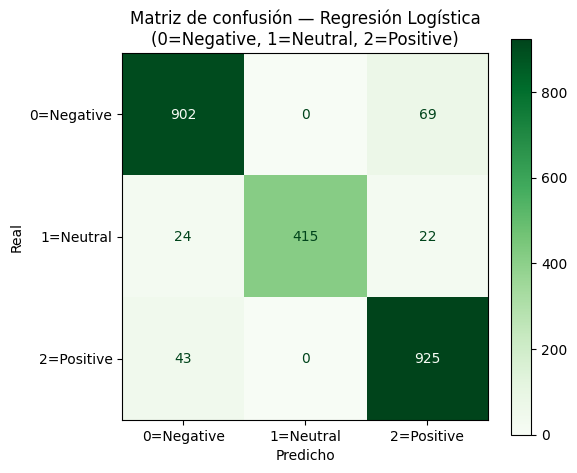

In [ ]:
from model_evaluation import get_confusion
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from config import PLOTS_DIR

cm, labels = get_confusion(model, X_test, y_test)
# Etiquetas con su codigo: 0=Negative, 1=Neutral, 2=Positive
disp_labels = [f'{i}={lab}' for i, lab in enumerate(labels)]
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(
    ax=ax, cmap='Greens', values_format='d', colorbar=True)
ax.set_title('Matriz de confusión — Regresión Logística\n'
             '(0=Negative, 1=Neutral, 2=Positive)')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout(); plt.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=130); plt.show()

**Lectura de la matriz:** la diagonal concentra los aciertos. El modelo **casi nunca confunde Negative (0) con Positive (2)** directamente; sus errores pasan por **Neutral (1)**, que es la frontera ambigua —comparte vocabulario con ambos extremos. Es el error esperable y razonable.

## 3. ¿Qué palabras usa el modelo? (interpretabilidad)
Ventaja de la Regresión Logística: podemos ver las palabras que más empujan hacia cada clase. Esto le permite a la agencia *explicar* sus alertas.

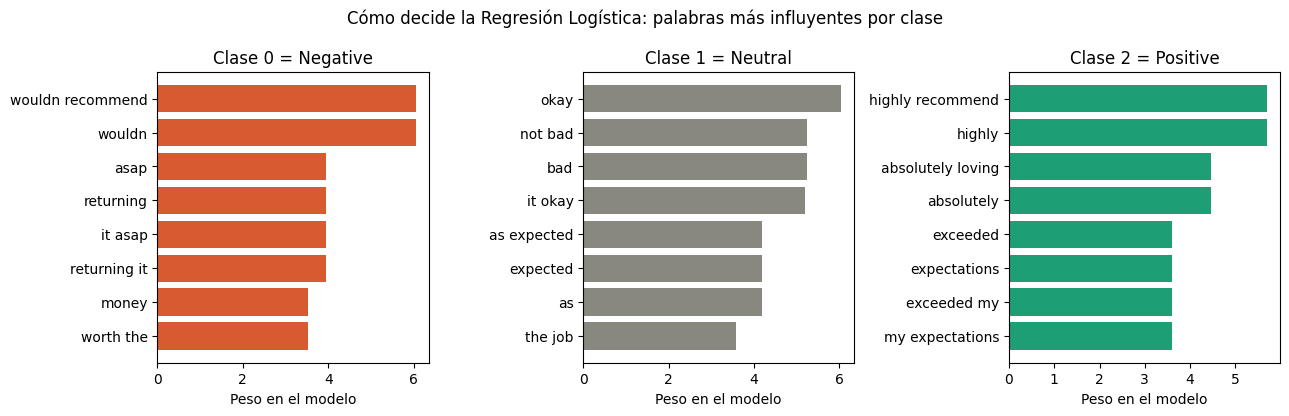

In [ ]:
from model_evaluation import top_terms_per_class
import numpy as np, matplotlib.pyplot as plt
from config import PLOTS_DIR

vec = model.named_steps['tfidf']; clf = model.named_steps['clf']
names = np.array(vec.get_feature_names_out())
colores = {'Negative':'#D85A30','Neutral':'#888780','Positive':'#1D9E75'}
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
for ax, idx in zip(axes, range(len(clf.classes_))):
    cls = clf.classes_[idx]
    top = np.argsort(clf.coef_[idx])[-8:]
    ax.barh(names[top], clf.coef_[idx][top], color=colores.get(cls,'#534AB7'))
    ax.set_title(f'Clase {idx} = {cls}'); ax.set_xlabel('Peso en el modelo')
fig.suptitle('Cómo decide la Regresión Logística: palabras más influyentes por clase')
plt.tight_layout(); plt.savefig(PLOTS_DIR / '05_como_decide.png', dpi=130); plt.show()

## 4. Temas descubiertos por el clustering (tono × tema)
Cruzamos los clusters con `topic_category` y con el sentimiento para mostrar que cada tema mezcla tonos: por eso ambos modelos se complementan.

In [ ]:
from model_training import build_text_features
from sklearn.cluster import KMeans
feat = build_text_features()
Xr = feat.fit_transform(df['text_content'].fillna(''))
df = df.copy(); df['cluster'] = KMeans(n_clusters=6, random_state=SEED, n_init=10).fit_predict(Xr)
tab = pd.crosstab(df['cluster'], df['sentiment_label'], normalize='index').round(2)
tab

sentiment_label,Negative,Neutral,Positive
cluster,,,
0,0.38,0.21,0.41
1,0.36,0.20,0.44
2,0.40,0.19,0.40
3,0.45,0.18,0.37
4,0.38,0.18,0.43
5,0.37,0.24,0.39


Cada cluster (tema) reparte su sentimiento entre positivo, negativo y neutro: el **tema es independiente del tono**. La combinación de ambos modelos da la matriz accionable *tema × tono* para la agencia.